- Some time periods in 2023 showed an offset in vertical wind component W.
- EddyPro allows to correct for such an offset.
- Here the output is compared from the original flux calcs without the W offset correction (2023_1), with the output that uses the offset correction (2023_02+. multiple time periods).
- The output from 2023_02+ is combined with the other data from that year (2023_01+, no offset correction needed) to get data for the full year.
- After the offset correction, fluxes look better, less noisy.

# Imports

In [2]:
import importlib.metadata
import warnings
from datetime import datetime

import pandas as pd
from diive.core.io.filereader import search_files, MultiDataFileReader
from diive.core.io.files import save_parquet

# pd.options.display.width = None
# pd.options.display.max_columns = None
pd.set_option('display.max_rows', 3000)
pd.set_option('display.max_columns', 3000)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.86.0


# Original 2023_1 flux calcs

In [18]:
# Search original files and store filepaths in list
SOURCEDIR = r"F:\TMP\testing_cha"
sourcefiles = search_files(searchdirs=SOURCEDIR, pattern='*')
sourcefiles

[WindowsPath('F:/TMP/testing_cha/2023_1_IRGA_eddypro_CH-CHA_FR-20240726-181748_fluxnet_2024-07-27T162051_adv.csv')]

In [19]:
# Read data from files to dataframe
d = MultiDataFileReader(filepaths=sourcefiles,
                        filetype='EDDYPRO-FLUXNET-CSV-30MIN',
                        output_middle_timestamp=True)
df = d.data_df
df

Reading file 2023_1_IRGA_eddypro_CH-CHA_FR-20240726-181748_fluxnet_2024-07-27T162051_adv.csv ...


,AIR_MV,AIR_DENSITY,AIR_RHO_CP,AIR_CP,AOA_METHOD,AXES_ROTATION_METHOD,BOWEN,BURBA_METHOD,BADM_LOCATION_LAT,BADM_LOCATION_LONG,BADM_LOCATION_ELEV,BADM_HEIGHTC,BADM_INST_SAMPLING_INT,BADM_INST_AVERAGING_INT,BADM_INST_MODEL_SA,BADM_INST_HEIGHT_SA,BADM_INST_SA_WIND_FORMAT,BADM_INST_SA_GILL_ALIGN,BADM_SA_OFFSET_NORTH,BADM_INST_MODEL_GA_CO2,BADM_INSTPAIR_NORTHWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INST_GA_CP_TUBE_LENGTH_GA_CO2,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_CO2,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_CO2,BADM_INST_MODEL_GA_H2O,BADM_INSTPAIR_NORTHWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INST_GA_CP_TUBE_LENGTH_GA_H2O,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_H2O,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_H2O,BADM_INST_MODEL_GA_CH4,BADM_INSTPAIR_NORTHWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INST_GA_CP_TUBE_LENGTH_GA_CH4,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_CH4,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_CH4,BADM_INST_MODEL_GA_NONE,BADM_INSTPAIR_NORTHWARD_SEP_GA_NONE,BADM_INSTPAIR_EASTWARD_SEP_GA_NONE,BADM_INSTPAIR_HEIGHT_SEP_GA_NONE,BADM_INST_GA_CP_TUBE_LENGTH_GA_NONE,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_NONE,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_NONE,CUSTOM_FILTER_NR,CO2_NR,CH4_NR,CO2_MEAS_TYPE,CO2_MOLAR_DENSITY,CO2_MIXING_RATIO,CO2,CH4_MEAS_TYPE,CH4_MOLAR_DENSITY,CH4_MIXING_RATIO,CH4,CO2_TLAG_ACTUAL,CO2_TLAG_USED,CO2_TLAG_NOMINAL,CO2_TLAG_MIN,CO2_TLAG_MAX,CH4_TLAG_ACTUAL,CH4_TLAG_USED,CH4_TLAG_NOMINAL,CH4_TLAG_MIN,CH4_TLAG_MAX,CO2_MEAS_MEDIAN,CH4_MEAS_MEDIAN,CO2_MEAS_P25,CH4_MEAS_P25,CO2_MEAS_P75,CH4_MEAS_P75,CO2_MEAS_SIGMA,CH4_MEAS_SIGMA,CO2_MEAS_SKW,CH4_MEAS_SKW,CO2_MEAS_KUR,CH4_MEAS_KUR,CO2_MEAS_H2O_MEAS_COV,CO2_MEAS_CH4_MEAS_COV,CO2_MEAS_NONE_MEAS_COV,CH4_MEAS_NONE_MEAS_COV,CO2_NUM_SPIKES,CH4_NUM_SPIKES,CUSTOM_FILTER_NREX,CO2_DIAG_NREX,CH4_DIAG_NREX,CO2_SPIKE_NREX,CH4_SPIKE_NREX,CO2_ABSLIM_NREX,CH4_ABSLIM_NREX,CO2_VM97_TEST,CH4_VM97_TEST,CO2_LGD,CH4_LGD,CO2_KID,CH4_KID,CO2_ZCD,CH4_ZCD,CUSTOM_DATA_SIZE_IRGA75_MEAN,CUSTOM_STATUS_CODE_IRGA75_MEAN,CUSTOM_GA_DIAG_CODE_IRGA75_MEAN,CUSTOM_AGC_MEAN,CUSTOM_FAST_T_MEAN,CUSTOM_AIR_P_MEAN,CUSTOM_COOLER_V_MEAN,DOY_START,DOY_END,DRYAIR_PARTIAL_PRESSURE,DRYAIR_DENSITY,DRYAIR_MV,DETRENDING_METHOD,DENTRENDING_TIME_CONSTANT,DISPLACEMENT_HEIGHT,EXPECT_NR,ET,ET_RANDUNC_HF,ET_UNCORR,ET_STAGE1,ET_STAGE2,ET_SCF,ET_CORRDIFF,ET_SSITC_TEST,FILENAME_HF,FILE_NR,FC_NR,FCH4_NR,FNONE_NR,FC,FH2O,FCH4,FNONE,FC_RANDUNC_HF,FH2O_RANDUNC_HF,FCH4_RANDUNC_HF,FNONE_RANDUNC_HF,FC_VADV,FH2O_VADV,FCH4_VADV,FNONE_VADV,FETCH_MAX,FETCH_OFFSET,FETCH_10,FETCH_30,FETCH_50,FETCH_70,FETCH_80,FETCH_90,FC_UNCORR,FH2O_UNCORR,FCH4_UNCORR,FNONE_UNCORR,FC_STAGE1,FH2O_STAGE1,FCH4_STAGE1,FNONE_STAGE1,FC_STAGE2,FH2O_STAGE2,FCH4_STAGE2,FNONE_STAGE2,FH2O_CELL_CO2,FH2O_CELL_CH4,FH2O_CELL_NONE,FC_SCF,FH2O_SCF,FCH4_SCF,FNONE_SCF,FC_CORRDIFF,FH2O_CORRDIFF,FCH4_CORRDIFF,FNONE_CORRDIFF,FC_NSR,FH2O_NSR,FCH4_NSR,FNONE_NSR,FC_SS,FH2O_SS,FCH4_SS,FNONE_SS,FC_SS_TEST,FH2O_SS_TEST,FCH4_SS_TEST,FNONE_SS_TEST,FC_SSITC_TEST,FH2O_SSITC_TEST,FCH4_SSITC_TEST,FNONE_SSITC_TEST,FOOTPRINT_MODEL,FILE_TIME_DURATION,H2O_NR,H_NR,H,H_RANDUNC_HF,H2O_MEAS_TYPE,H2O_MOLAR_DENSITY,H2O_MIXING_RATIO,H2O,H2O_TLAG_ACTUAL,H2O_TLAG_USED,H2O_TLAG_NOMINAL,H2O_TLAG_MIN,H2O_TLAG_MAX,H2O_MEAS_MEDIAN,H2O_MEAS_P25,H2O_MEAS_P75,H2O_MEAS_SIGMA,H2O_MEAS_SKW,H2O_MEAS_KUR,H2O_MEAS_CH4_MEAS_COV,H2O_MEAS_NONE_MEAS_COV,H_UNCORR,H_STAGE1,H_STAGE2,H_CELL_CO2,H_CELL_H2O,H_CELL_CH4,H_CELL_NONE,H_BU_BOT,H_BU_TOP,H_BU_SPAR,H_SCF,H2O_NUM_SPIKES,H2O_DIAG_NREX,H2O_SPIKE_NREX,H2O_ABSLIM_NREX,H2O_VM97_TEST,H2O_LGD,H2O_KID,H2O_ZCD,H_CORRDIFF,H_NSR,H_SS,H_SS_TEST,H_SSITC_TEST,HPATH_SA,HPATH_GA_CO2,HPATH_GA_H2O,HPATH_GA_CH4,HPATH_GA_NONE,INST_LI7200_HEAD_DETECT,INST_LI7200_T_OUT,INST_LI7200_T_IN,INST_LI7200_AUX_IN,INST_LI7200_DELTA_P,INST_LI7200_CHOPPER,INST_LI7200_DETECTOR,INST_LI7200_PLL,INST_LI7200_SYNC,INST_LI7500_CHOPPER,INST_LI7500_DETECTOR,INST_LI7500_PLL,INST_LI7500_SYNC,INST_LI7700_NOT_READY,INST_LI7700_NO_S

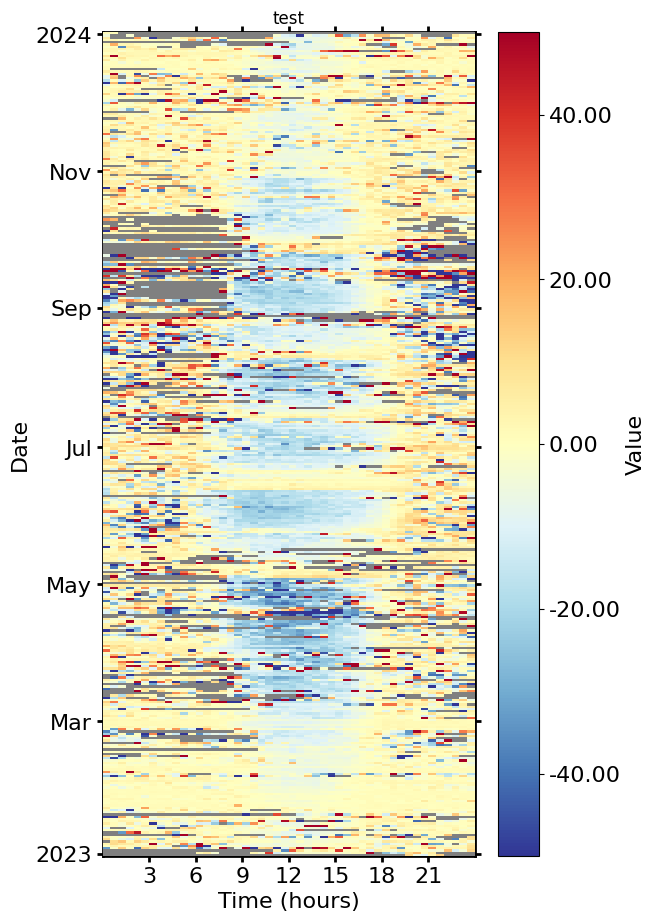

In [20]:
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
hm = HeatmapDateTime(series=df['FC'], title="test", vmin=-50, vmax=50).plot()

# Checking merging

In [3]:
# Search original files and store filepaths in list
SOURCEDIR = r"../0_data/RESULTS-IRGA-Level-1_fluxnet_2005-2024/"
sourcefiles = search_files(searchdirs=SOURCEDIR, pattern='*')

## Only 2023_01+

In [4]:
usefiles = [s for s in sourcefiles if "2023_01" in str(s)]
usefiles

[WindowsPath('../0_data/RESULTS-IRGA-Level-1_fluxnet_2005-2024/2023_01+eddypro_CH-CHA_FR-20250303-102224_fluxnet_2025-03-04T015312_adv.csv')]

In [5]:
# Read data from files to dataframe
d = MultiDataFileReader(filepaths=usefiles,
                        filetype='EDDYPRO-FLUXNET-CSV-30MIN',
                        output_middle_timestamp=True)
df = d.data_df
df

Reading file 2023_01+eddypro_CH-CHA_FR-20250303-102224_fluxnet_2025-03-04T015312_adv.csv ...


,AIR_MV,AIR_DENSITY,AIR_RHO_CP,AIR_CP,AOA_METHOD,AXES_ROTATION_METHOD,BOWEN,BURBA_METHOD,BADM_LOCATION_LAT,BADM_LOCATION_LONG,BADM_LOCATION_ELEV,BADM_HEIGHTC,BADM_INST_SAMPLING_INT,BADM_INST_AVERAGING_INT,BADM_INST_MODEL_SA,BADM_INST_HEIGHT_SA,BADM_INST_SA_WIND_FORMAT,BADM_INST_SA_GILL_ALIGN,BADM_SA_OFFSET_NORTH,BADM_INST_MODEL_GA_CO2,BADM_INSTPAIR_NORTHWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INST_GA_CP_TUBE_LENGTH_GA_CO2,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_CO2,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_CO2,BADM_INST_MODEL_GA_H2O,BADM_INSTPAIR_NORTHWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INST_GA_CP_TUBE_LENGTH_GA_H2O,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_H2O,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_H2O,BADM_INST_MODEL_GA_CH4,BADM_INSTPAIR_NORTHWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INST_GA_CP_TUBE_LENGTH_GA_CH4,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_CH4,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_CH4,BADM_INST_MODEL_GA_NONE,BADM_INSTPAIR_NORTHWARD_SEP_GA_NONE,BADM_INSTPAIR_EASTWARD_SEP_GA_NONE,BADM_INSTPAIR_HEIGHT_SEP_GA_NONE,BADM_INST_GA_CP_TUBE_LENGTH_GA_NONE,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_NONE,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_NONE,CUSTOM_FILTER_NR,CO2_NR,CH4_NR,CO2_MEAS_TYPE,CO2_MOLAR_DENSITY,CO2_MIXING_RATIO,CO2,CH4_MEAS_TYPE,CH4_MOLAR_DENSITY,CH4_MIXING_RATIO,CH4,CO2_TLAG_ACTUAL,CO2_TLAG_USED,CO2_TLAG_NOMINAL,CO2_TLAG_MIN,CO2_TLAG_MAX,CH4_TLAG_ACTUAL,CH4_TLAG_USED,CH4_TLAG_NOMINAL,CH4_TLAG_MIN,CH4_TLAG_MAX,CO2_MEAS_MEDIAN,CH4_MEAS_MEDIAN,CO2_MEAS_P25,CH4_MEAS_P25,CO2_MEAS_P75,CH4_MEAS_P75,CO2_MEAS_SIGMA,CH4_MEAS_SIGMA,CO2_MEAS_SKW,CH4_MEAS_SKW,CO2_MEAS_KUR,CH4_MEAS_KUR,CO2_MEAS_H2O_MEAS_COV,CO2_MEAS_CH4_MEAS_COV,CO2_MEAS_NONE_MEAS_COV,CH4_MEAS_NONE_MEAS_COV,CO2_NUM_SPIKES,CH4_NUM_SPIKES,CUSTOM_FILTER_NREX,CO2_DIAG_NREX,CH4_DIAG_NREX,CO2_SPIKE_NREX,CH4_SPIKE_NREX,CO2_ABSLIM_NREX,CH4_ABSLIM_NREX,CO2_VM97_TEST,CH4_VM97_TEST,CO2_LGD,CH4_LGD,CO2_KID,CH4_KID,CO2_ZCD,CH4_ZCD,CUSTOM_DATA_SIZE_IRGA75_MEAN,CUSTOM_STATUS_CODE_IRGA75_MEAN,CUSTOM_GA_DIAG_CODE_IRGA75_MEAN,CUSTOM_AGC_MEAN,CUSTOM_FAST_T_MEAN,CUSTOM_AIR_P_MEAN,CUSTOM_COOLER_V_MEAN,DOY_START,DOY_END,DRYAIR_PARTIAL_PRESSURE,DRYAIR_DENSITY,DRYAIR_MV,DETRENDING_METHOD,DENTRENDING_TIME_CONSTANT,DISPLACEMENT_HEIGHT,EXPECT_NR,ET,ET_RANDUNC_HF,ET_UNCORR,ET_STAGE1,ET_STAGE2,ET_SCF,ET_CORRDIFF,ET_SSITC_TEST,FILENAME_HF,FILE_NR,FC_NR,FCH4_NR,FNONE_NR,FC,FH2O,FCH4,FNONE,FC_RANDUNC_HF,FH2O_RANDUNC_HF,FCH4_RANDUNC_HF,FNONE_RANDUNC_HF,FC_VADV,FH2O_VADV,FCH4_VADV,FNONE_VADV,FETCH_MAX,FETCH_OFFSET,FETCH_10,FETCH_30,FETCH_50,FETCH_70,FETCH_80,FETCH_90,FC_UNCORR,FH2O_UNCORR,FCH4_UNCORR,FNONE_UNCORR,FC_STAGE1,FH2O_STAGE1,FCH4_STAGE1,FNONE_STAGE1,FC_STAGE2,FH2O_STAGE2,FCH4_STAGE2,FNONE_STAGE2,FH2O_CELL_CO2,FH2O_CELL_CH4,FH2O_CELL_NONE,FC_SCF,FH2O_SCF,FCH4_SCF,FNONE_SCF,FC_CORRDIFF,FH2O_CORRDIFF,FCH4_CORRDIFF,FNONE_CORRDIFF,FC_NSR,FH2O_NSR,FCH4_NSR,FNONE_NSR,FC_SS,FH2O_SS,FCH4_SS,FNONE_SS,FC_SS_TEST,FH2O_SS_TEST,FCH4_SS_TEST,FNONE_SS_TEST,FC_SSITC_TEST,FH2O_SSITC_TEST,FCH4_SSITC_TEST,FNONE_SSITC_TEST,FOOTPRINT_MODEL,FILE_TIME_DURATION,H2O_NR,H_NR,H,H_RANDUNC_HF,H2O_MEAS_TYPE,H2O_MOLAR_DENSITY,H2O_MIXING_RATIO,H2O,H2O_TLAG_ACTUAL,H2O_TLAG_USED,H2O_TLAG_NOMINAL,H2O_TLAG_MIN,H2O_TLAG_MAX,H2O_MEAS_MEDIAN,H2O_MEAS_P25,H2O_MEAS_P75,H2O_MEAS_SIGMA,H2O_MEAS_SKW,H2O_MEAS_KUR,H2O_MEAS_CH4_MEAS_COV,H2O_MEAS_NONE_MEAS_COV,H_UNCORR,H_STAGE1,H_STAGE2,H_CELL_CO2,H_CELL_H2O,H_CELL_CH4,H_CELL_NONE,H_BU_BOT,H_BU_TOP,H_BU_SPAR,H_SCF,H2O_NUM_SPIKES,H2O_DIAG_NREX,H2O_SPIKE_NREX,H2O_ABSLIM_NREX,H2O_VM97_TEST,H2O_LGD,H2O_KID,H2O_ZCD,H_CORRDIFF,H_NSR,H_SS,H_SS_TEST,H_SSITC_TEST,HPATH_SA,HPATH_GA_CO2,HPATH_GA_H2O,HPATH_GA_CH4,HPATH_GA_NONE,INST_LI7200_HEAD_DETECT,INST_LI7200_T_OUT,INST_LI7200_T_IN,INST_LI7200_AUX_IN,INST_LI7200_DELTA_P,INST_LI7200_CHOPPER,INST_LI7200_DETECTOR,INST_LI7200_PLL,INST_LI7200_SYNC,INST_LI7500_CHOPPER,INST_LI7500_DETECTOR,INST_LI7500_PLL,INST_LI7500_SYNC,INST_LI7700_NOT_READY,INST_LI7700_NO_S

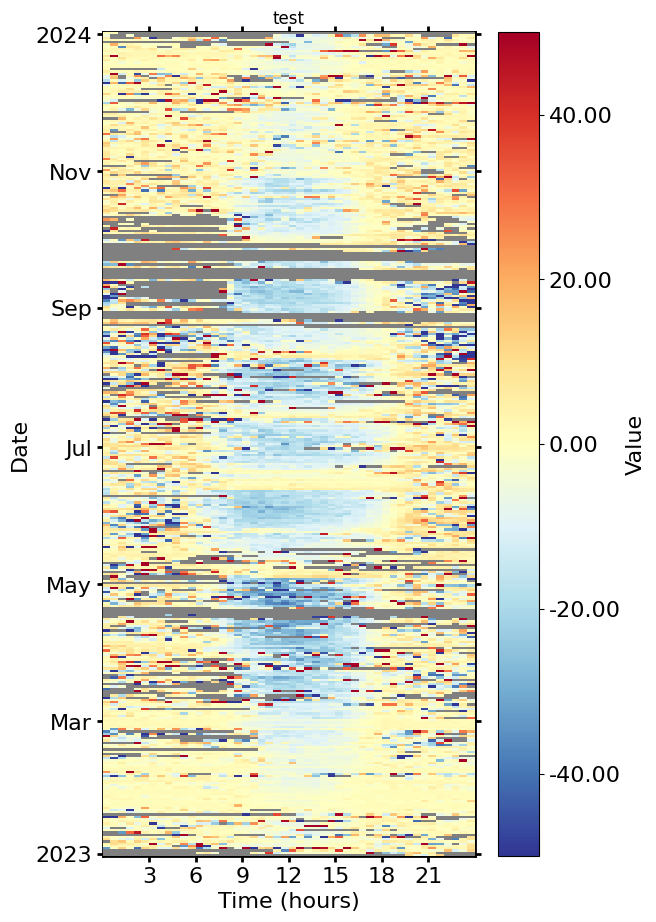

In [6]:
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
hm = HeatmapDateTime(series=df['FC'], title="test", vmin=-50, vmax=50).plot()

## Only 2023_02+

In [7]:
usefiles = [s for s in sourcefiles if "2023_02" in str(s)]
usefiles

[WindowsPath('../0_data/RESULTS-IRGA-Level-1_fluxnet_2005-2024/2023_02+eddypro_CH-CHA_FR-20250304-093959_fluxnet_2025-03-04T110501_adv.csv')]

In [8]:
# Read data from files to dataframe
d = MultiDataFileReader(filepaths=usefiles,
                        filetype='EDDYPRO-FLUXNET-CSV-30MIN',
                        output_middle_timestamp=True)
df = d.data_df
df

Reading file 2023_02+eddypro_CH-CHA_FR-20250304-093959_fluxnet_2025-03-04T110501_adv.csv ...


,AIR_MV,AIR_DENSITY,AIR_RHO_CP,AIR_CP,AOA_METHOD,AXES_ROTATION_METHOD,BOWEN,BURBA_METHOD,BADM_LOCATION_LAT,BADM_LOCATION_LONG,BADM_LOCATION_ELEV,BADM_HEIGHTC,BADM_INST_SAMPLING_INT,BADM_INST_AVERAGING_INT,BADM_INST_MODEL_SA,BADM_INST_HEIGHT_SA,BADM_INST_SA_WIND_FORMAT,BADM_INST_SA_GILL_ALIGN,BADM_SA_OFFSET_NORTH,BADM_INST_MODEL_GA_CO2,BADM_INSTPAIR_NORTHWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INST_GA_CP_TUBE_LENGTH_GA_CO2,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_CO2,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_CO2,BADM_INST_MODEL_GA_H2O,BADM_INSTPAIR_NORTHWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INST_GA_CP_TUBE_LENGTH_GA_H2O,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_H2O,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_H2O,BADM_INST_MODEL_GA_CH4,BADM_INSTPAIR_NORTHWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INST_GA_CP_TUBE_LENGTH_GA_CH4,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_CH4,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_CH4,BADM_INST_MODEL_GA_NONE,BADM_INSTPAIR_NORTHWARD_SEP_GA_NONE,BADM_INSTPAIR_EASTWARD_SEP_GA_NONE,BADM_INSTPAIR_HEIGHT_SEP_GA_NONE,BADM_INST_GA_CP_TUBE_LENGTH_GA_NONE,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_NONE,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_NONE,CUSTOM_FILTER_NR,CO2_NR,CH4_NR,CO2_MEAS_TYPE,CO2_MOLAR_DENSITY,CO2_MIXING_RATIO,CO2,CH4_MEAS_TYPE,CH4_MOLAR_DENSITY,CH4_MIXING_RATIO,CH4,CO2_TLAG_ACTUAL,CO2_TLAG_USED,CO2_TLAG_NOMINAL,CO2_TLAG_MIN,CO2_TLAG_MAX,CH4_TLAG_ACTUAL,CH4_TLAG_USED,CH4_TLAG_NOMINAL,CH4_TLAG_MIN,CH4_TLAG_MAX,CO2_MEAS_MEDIAN,CH4_MEAS_MEDIAN,CO2_MEAS_P25,CH4_MEAS_P25,CO2_MEAS_P75,CH4_MEAS_P75,CO2_MEAS_SIGMA,CH4_MEAS_SIGMA,CO2_MEAS_SKW,CH4_MEAS_SKW,CO2_MEAS_KUR,CH4_MEAS_KUR,CO2_MEAS_H2O_MEAS_COV,CO2_MEAS_CH4_MEAS_COV,CO2_MEAS_NONE_MEAS_COV,CH4_MEAS_NONE_MEAS_COV,CO2_NUM_SPIKES,CH4_NUM_SPIKES,CUSTOM_FILTER_NREX,CO2_DIAG_NREX,CH4_DIAG_NREX,CO2_SPIKE_NREX,CH4_SPIKE_NREX,CO2_ABSLIM_NREX,CH4_ABSLIM_NREX,CO2_VM97_TEST,CH4_VM97_TEST,CO2_LGD,CH4_LGD,CO2_KID,CH4_KID,CO2_ZCD,CH4_ZCD,CUSTOM_DATA_SIZE_IRGA75_MEAN,CUSTOM_STATUS_CODE_IRGA75_MEAN,CUSTOM_GA_DIAG_CODE_IRGA75_MEAN,CUSTOM_AGC_MEAN,CUSTOM_FAST_T_MEAN,CUSTOM_AIR_P_MEAN,CUSTOM_COOLER_V_MEAN,DOY_START,DOY_END,DRYAIR_PARTIAL_PRESSURE,DRYAIR_DENSITY,DRYAIR_MV,DETRENDING_METHOD,DENTRENDING_TIME_CONSTANT,DISPLACEMENT_HEIGHT,EXPECT_NR,ET,ET_RANDUNC_HF,ET_UNCORR,ET_STAGE1,ET_STAGE2,ET_SCF,ET_CORRDIFF,ET_SSITC_TEST,FILENAME_HF,FILE_NR,FC_NR,FCH4_NR,FNONE_NR,FC,FH2O,FCH4,FNONE,FC_RANDUNC_HF,FH2O_RANDUNC_HF,FCH4_RANDUNC_HF,FNONE_RANDUNC_HF,FC_VADV,FH2O_VADV,FCH4_VADV,FNONE_VADV,FETCH_MAX,FETCH_OFFSET,FETCH_10,FETCH_30,FETCH_50,FETCH_70,FETCH_80,FETCH_90,FC_UNCORR,FH2O_UNCORR,FCH4_UNCORR,FNONE_UNCORR,FC_STAGE1,FH2O_STAGE1,FCH4_STAGE1,FNONE_STAGE1,FC_STAGE2,FH2O_STAGE2,FCH4_STAGE2,FNONE_STAGE2,FH2O_CELL_CO2,FH2O_CELL_CH4,FH2O_CELL_NONE,FC_SCF,FH2O_SCF,FCH4_SCF,FNONE_SCF,FC_CORRDIFF,FH2O_CORRDIFF,FCH4_CORRDIFF,FNONE_CORRDIFF,FC_NSR,FH2O_NSR,FCH4_NSR,FNONE_NSR,FC_SS,FH2O_SS,FCH4_SS,FNONE_SS,FC_SS_TEST,FH2O_SS_TEST,FCH4_SS_TEST,FNONE_SS_TEST,FC_SSITC_TEST,FH2O_SSITC_TEST,FCH4_SSITC_TEST,FNONE_SSITC_TEST,FOOTPRINT_MODEL,FILE_TIME_DURATION,H2O_NR,H_NR,H,H_RANDUNC_HF,H2O_MEAS_TYPE,H2O_MOLAR_DENSITY,H2O_MIXING_RATIO,H2O,H2O_TLAG_ACTUAL,H2O_TLAG_USED,H2O_TLAG_NOMINAL,H2O_TLAG_MIN,H2O_TLAG_MAX,H2O_MEAS_MEDIAN,H2O_MEAS_P25,H2O_MEAS_P75,H2O_MEAS_SIGMA,H2O_MEAS_SKW,H2O_MEAS_KUR,H2O_MEAS_CH4_MEAS_COV,H2O_MEAS_NONE_MEAS_COV,H_UNCORR,H_STAGE1,H_STAGE2,H_CELL_CO2,H_CELL_H2O,H_CELL_CH4,H_CELL_NONE,H_BU_BOT,H_BU_TOP,H_BU_SPAR,H_SCF,H2O_NUM_SPIKES,H2O_DIAG_NREX,H2O_SPIKE_NREX,H2O_ABSLIM_NREX,H2O_VM97_TEST,H2O_LGD,H2O_KID,H2O_ZCD,H_CORRDIFF,H_NSR,H_SS,H_SS_TEST,H_SSITC_TEST,HPATH_SA,HPATH_GA_CO2,HPATH_GA_H2O,HPATH_GA_CH4,HPATH_GA_NONE,INST_LI7200_HEAD_DETECT,INST_LI7200_T_OUT,INST_LI7200_T_IN,INST_LI7200_AUX_IN,INST_LI7200_DELTA_P,INST_LI7200_CHOPPER,INST_LI7200_DETECTOR,INST_LI7200_PLL,INST_LI7200_SYNC,INST_LI7500_CHOPPER,INST_LI7500_DETECTOR,INST_LI7500_PLL,INST_LI7500_SYNC,INST_LI7700_NOT_READY,INST_LI7700_NO_S

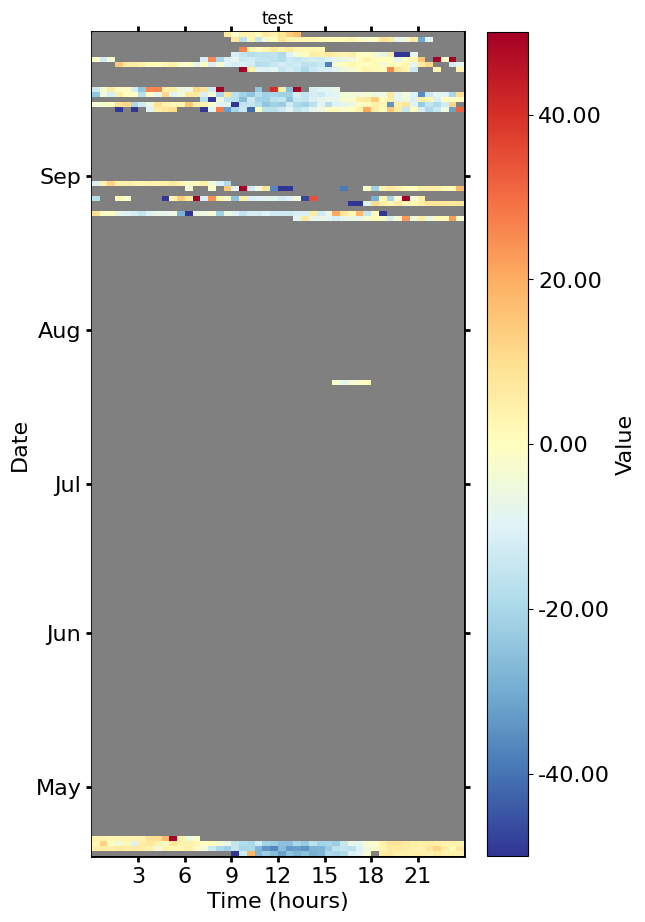

In [9]:
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
hm = HeatmapDateTime(series=df['FC'], title="test", vmin=-50, vmax=50).plot()

## 2023_01+ combined with 2023_02+

In [10]:
usefiles = [s for s in sourcefiles if "2023_0" in str(s)]
usefiles

[WindowsPath('../0_data/RESULTS-IRGA-Level-1_fluxnet_2005-2024/2023_01+eddypro_CH-CHA_FR-20250303-102224_fluxnet_2025-03-04T015312_adv.csv'),
 WindowsPath('../0_data/RESULTS-IRGA-Level-1_fluxnet_2005-2024/2023_02+eddypro_CH-CHA_FR-20250304-093959_fluxnet_2025-03-04T110501_adv.csv')]

In [11]:
# Read data from files to dataframe
d = MultiDataFileReader(filepaths=usefiles,
                        filetype='EDDYPRO-FLUXNET-CSV-30MIN',
                        output_middle_timestamp=True)
df = d.data_df
df

Reading file 2023_01+eddypro_CH-CHA_FR-20250303-102224_fluxnet_2025-03-04T015312_adv.csv ...
Reading file 2023_02+eddypro_CH-CHA_FR-20250304-093959_fluxnet_2025-03-04T110501_adv.csv ...


,AIR_MV,AIR_DENSITY,AIR_RHO_CP,AIR_CP,AOA_METHOD,AXES_ROTATION_METHOD,BOWEN,BURBA_METHOD,BADM_LOCATION_LAT,BADM_LOCATION_LONG,BADM_LOCATION_ELEV,BADM_HEIGHTC,BADM_INST_SAMPLING_INT,BADM_INST_AVERAGING_INT,BADM_INST_MODEL_SA,BADM_INST_HEIGHT_SA,BADM_INST_SA_WIND_FORMAT,BADM_INST_SA_GILL_ALIGN,BADM_SA_OFFSET_NORTH,BADM_INST_MODEL_GA_CO2,BADM_INSTPAIR_NORTHWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INST_GA_CP_TUBE_LENGTH_GA_CO2,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_CO2,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_CO2,BADM_INST_MODEL_GA_H2O,BADM_INSTPAIR_NORTHWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INST_GA_CP_TUBE_LENGTH_GA_H2O,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_H2O,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_H2O,BADM_INST_MODEL_GA_CH4,BADM_INSTPAIR_NORTHWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INST_GA_CP_TUBE_LENGTH_GA_CH4,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_CH4,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_CH4,BADM_INST_MODEL_GA_NONE,BADM_INSTPAIR_NORTHWARD_SEP_GA_NONE,BADM_INSTPAIR_EASTWARD_SEP_GA_NONE,BADM_INSTPAIR_HEIGHT_SEP_GA_NONE,BADM_INST_GA_CP_TUBE_LENGTH_GA_NONE,BADM_INST_GA_CP_TUBE_IN_DIAM_GA_NONE,BADM_INST_GA_CP_TUBE_FLOW_RATE_GA_NONE,CUSTOM_FILTER_NR,CO2_NR,CH4_NR,CO2_MEAS_TYPE,CO2_MOLAR_DENSITY,CO2_MIXING_RATIO,CO2,CH4_MEAS_TYPE,CH4_MOLAR_DENSITY,CH4_MIXING_RATIO,CH4,CO2_TLAG_ACTUAL,CO2_TLAG_USED,CO2_TLAG_NOMINAL,CO2_TLAG_MIN,CO2_TLAG_MAX,CH4_TLAG_ACTUAL,CH4_TLAG_USED,CH4_TLAG_NOMINAL,CH4_TLAG_MIN,CH4_TLAG_MAX,CO2_MEAS_MEDIAN,CH4_MEAS_MEDIAN,CO2_MEAS_P25,CH4_MEAS_P25,CO2_MEAS_P75,CH4_MEAS_P75,CO2_MEAS_SIGMA,CH4_MEAS_SIGMA,CO2_MEAS_SKW,CH4_MEAS_SKW,CO2_MEAS_KUR,CH4_MEAS_KUR,CO2_MEAS_H2O_MEAS_COV,CO2_MEAS_CH4_MEAS_COV,CO2_MEAS_NONE_MEAS_COV,CH4_MEAS_NONE_MEAS_COV,CO2_NUM_SPIKES,CH4_NUM_SPIKES,CUSTOM_FILTER_NREX,CO2_DIAG_NREX,CH4_DIAG_NREX,CO2_SPIKE_NREX,CH4_SPIKE_NREX,CO2_ABSLIM_NREX,CH4_ABSLIM_NREX,CO2_VM97_TEST,CH4_VM97_TEST,CO2_LGD,CH4_LGD,CO2_KID,CH4_KID,CO2_ZCD,CH4_ZCD,CUSTOM_DATA_SIZE_IRGA75_MEAN,CUSTOM_STATUS_CODE_IRGA75_MEAN,CUSTOM_GA_DIAG_CODE_IRGA75_MEAN,CUSTOM_AGC_MEAN,CUSTOM_FAST_T_MEAN,CUSTOM_AIR_P_MEAN,CUSTOM_COOLER_V_MEAN,DOY_START,DOY_END,DRYAIR_PARTIAL_PRESSURE,DRYAIR_DENSITY,DRYAIR_MV,DETRENDING_METHOD,DENTRENDING_TIME_CONSTANT,DISPLACEMENT_HEIGHT,EXPECT_NR,ET,ET_RANDUNC_HF,ET_UNCORR,ET_STAGE1,ET_STAGE2,ET_SCF,ET_CORRDIFF,ET_SSITC_TEST,FILENAME_HF,FILE_NR,FC_NR,FCH4_NR,FNONE_NR,FC,FH2O,FCH4,FNONE,FC_RANDUNC_HF,FH2O_RANDUNC_HF,FCH4_RANDUNC_HF,FNONE_RANDUNC_HF,FC_VADV,FH2O_VADV,FCH4_VADV,FNONE_VADV,FETCH_MAX,FETCH_OFFSET,FETCH_10,FETCH_30,FETCH_50,FETCH_70,FETCH_80,FETCH_90,FC_UNCORR,FH2O_UNCORR,FCH4_UNCORR,FNONE_UNCORR,FC_STAGE1,FH2O_STAGE1,FCH4_STAGE1,FNONE_STAGE1,FC_STAGE2,FH2O_STAGE2,FCH4_STAGE2,FNONE_STAGE2,FH2O_CELL_CO2,FH2O_CELL_CH4,FH2O_CELL_NONE,FC_SCF,FH2O_SCF,FCH4_SCF,FNONE_SCF,FC_CORRDIFF,FH2O_CORRDIFF,FCH4_CORRDIFF,FNONE_CORRDIFF,FC_NSR,FH2O_NSR,FCH4_NSR,FNONE_NSR,FC_SS,FH2O_SS,FCH4_SS,FNONE_SS,FC_SS_TEST,FH2O_SS_TEST,FCH4_SS_TEST,FNONE_SS_TEST,FC_SSITC_TEST,FH2O_SSITC_TEST,FCH4_SSITC_TEST,FNONE_SSITC_TEST,FOOTPRINT_MODEL,FILE_TIME_DURATION,H2O_NR,H_NR,H,H_RANDUNC_HF,H2O_MEAS_TYPE,H2O_MOLAR_DENSITY,H2O_MIXING_RATIO,H2O,H2O_TLAG_ACTUAL,H2O_TLAG_USED,H2O_TLAG_NOMINAL,H2O_TLAG_MIN,H2O_TLAG_MAX,H2O_MEAS_MEDIAN,H2O_MEAS_P25,H2O_MEAS_P75,H2O_MEAS_SIGMA,H2O_MEAS_SKW,H2O_MEAS_KUR,H2O_MEAS_CH4_MEAS_COV,H2O_MEAS_NONE_MEAS_COV,H_UNCORR,H_STAGE1,H_STAGE2,H_CELL_CO2,H_CELL_H2O,H_CELL_CH4,H_CELL_NONE,H_BU_BOT,H_BU_TOP,H_BU_SPAR,H_SCF,H2O_NUM_SPIKES,H2O_DIAG_NREX,H2O_SPIKE_NREX,H2O_ABSLIM_NREX,H2O_VM97_TEST,H2O_LGD,H2O_KID,H2O_ZCD,H_CORRDIFF,H_NSR,H_SS,H_SS_TEST,H_SSITC_TEST,HPATH_SA,HPATH_GA_CO2,HPATH_GA_H2O,HPATH_GA_CH4,HPATH_GA_NONE,INST_LI7200_HEAD_DETECT,INST_LI7200_T_OUT,INST_LI7200_T_IN,INST_LI7200_AUX_IN,INST_LI7200_DELTA_P,INST_LI7200_CHOPPER,INST_LI7200_DETECTOR,INST_LI7200_PLL,INST_LI7200_SYNC,INST_LI7500_CHOPPER,INST_LI7500_DETECTOR,INST_LI7500_PLL,INST_LI7500_SYNC,INST_LI7700_NOT_READY,INST_LI7700_NO_S

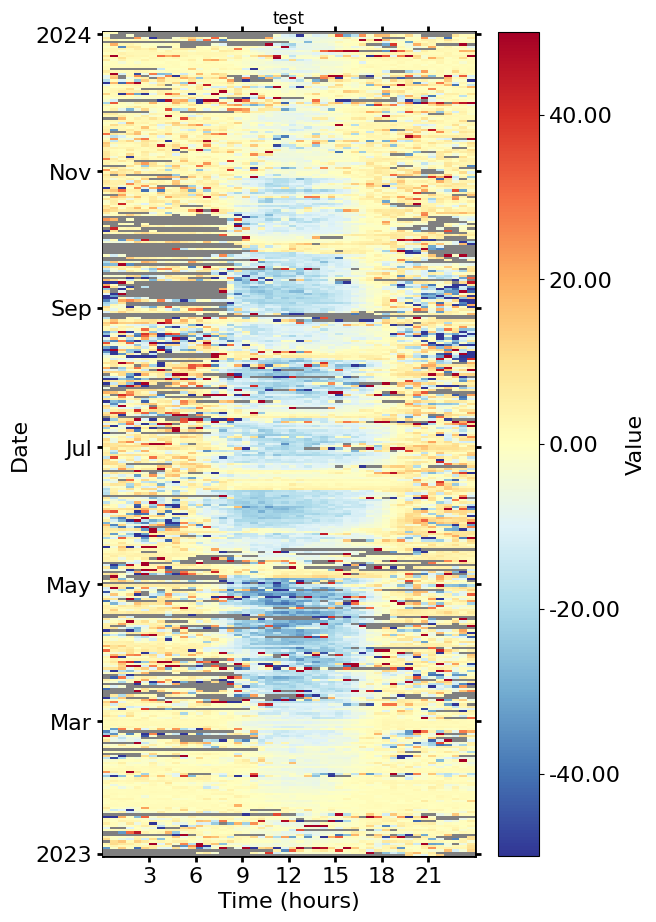

In [12]:
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
hm = HeatmapDateTime(series=df['FC'], title="test", vmin=-50, vmax=50).plot()

# **End of notebook**.

In [13]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-03-04 15:14:07
